In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.nn import Parameter
from torch.nn import init
from torch.nn.modules.module import Module
from torch.nn.modules.linear import Linear
from torch.nn.modules.conv import _ConvNd
from torch.nn.modules.utils import _pair
from torch.nn.parameter import Parameter


In [ ]:

from transformers import ( # type: ignore
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
)

# Load weights

config ={
            "in_channels": 3,
            "num_classes": 10,
            "input_size": (32, 32),
        }

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
path = "/home/user/Projects/Federated_Learning/eris/experiments_unbiased_pareto/fedavg_llm/checkpoints/distilbert-base-uncased/imdb/model_22.pth"
model.load_state_dict(torch.load(path, weights_only=False))



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


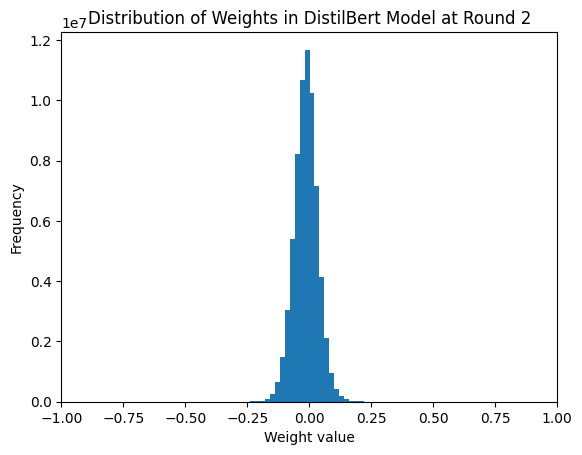

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


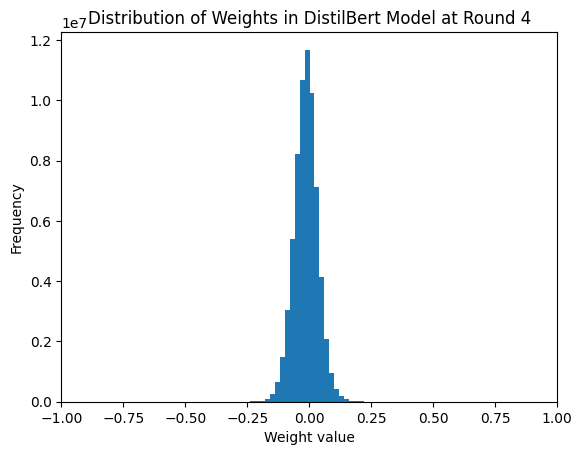

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


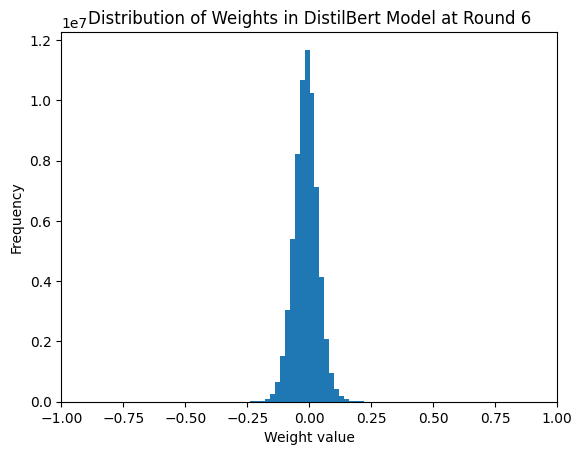

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
# Flatten the parameters
for i in range(2,22,2):

    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
    path = f"/home/user/Projects/Federated_Learning/eris/experiments_unbiased_pareto/fedavg_llm/checkpoints/distilbert-base-uncased/imdb/model_{i}.pth"
    model.load_state_dict(torch.load(path, weights_only=False))
    
    flat_params = []
    for param in model.parameters():
        flat_params.extend(param.data.cpu().numpy().ravel())
    
    # remove values our
    flat_params = np.array([x for x in flat_params if -1 <= x <= 1])

    # Plot the distribution
    plt.hist(flat_params, bins=100)
    plt.xlabel("Weight value")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Weights in DistilBert Model at Round {i}")
    plt.xlim(-1, 1)  
    plt.show()

In [ ]:
import os
from tqdm import tqdm
os.makedirs("./weight distributions/", exist_ok=True)
# Flatten the parameters
for i in tqdm(range(2,22,2)):

    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
    path = f"/home/user/Projects/Federated_Learning/eris/experiments_unbiased_pareto/fedavg_llm/checkpoints/distilbert-base-uncased/imdb/model_{i}.pth"
    model.load_state_dict(torch.load(path, weights_only=False))
    
    flat_params = []
    for param in model.parameters():
        flat_params.extend(param.data.cpu().numpy().ravel())
    
    # remove values our
    flat_params = np.array([x for x in flat_params if -1 <= x <= 1])

    # save the distribution
    np.save(f"./weight distributions/weights_{i}.npy", flat_params)

  0%|          | 0/10 [00:00<?, ?it/s]Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 10%|█         | 1/10 [03:30<31:37, 210.85s/it]Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 20%|██        | 2/10 [07:03<28:16, 212.08s/it]Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classif

In [11]:
# read two distributions
import numpy as np
import matplotlib.pyplot as plt

x = np.load("./weight distributions/weights_2.npy")
y = np.load("./weight distributions/weights_4.npy")
# subtract the two distributions
diff = x - y
diff.sum()

-0.62317747